# Scraping Books

In [6]:
import sys

import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

In [24]:
def fetch_page(page):
    url = f"http://books.toscrape.com/catalogue/page-{page+1}.html"
    response = requests.get(url, headers = {"Accept-Language":"en-US"})
    soup = BeautifulSoup(response.content, "html.parser")
    return soup
    

In [25]:
def parse_rating(rating_classes):
    ratings = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    for rating in ratings:
        if rating in rating_classes:
            return ratings[rating]

In [ ]:
books_dict = { 'Title': [], 'Price': [], 'Rating': [] }

def all_books_df(max_page):
    
    for page in range(max_page):
        soup = fetch_page(page)
        for book_html in soup.find_all(class_ = "product_pod"):
            books_dict['Title'].append(book_html.find("h3").find("a").string)
            books_dict['Price'].append(float(book_html.find(class_ = "price_color").string.strip('£')))

            # Find the star rating and use parse_rating to convert it to numbers
            stars_html = book_html.find(class_ = "star-rating")
            books_dict['Rating'].append(parse_rating(stars_html.attrs['class']))

    return pd.DataFrame(books_dict)


## Creating the `books_df`

In [27]:
books_df = all_books_df(50)
books_df.shape

(1000, 3)

### Visualizing

In [28]:
books_df.head()

,Title,Price,Rating
0,A Light in the ...,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History ...,54.23,5


<Axes: xlabel='Rating'>

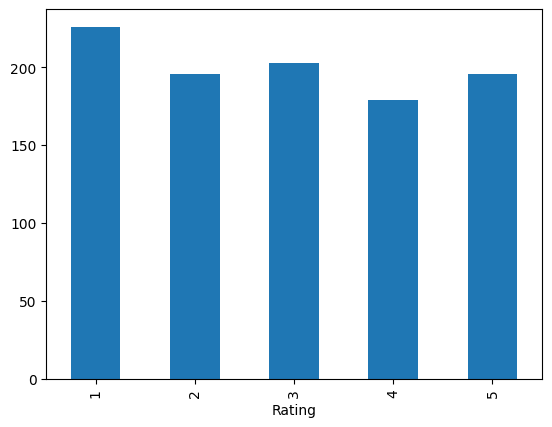

In [29]:
books_df.groupby("Rating").count()["Title"].plot(kind="bar")


<Axes: >

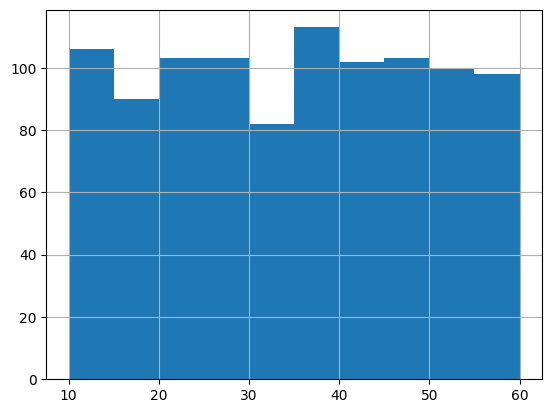

In [30]:
books_df['Price'].hist()

In [32]:
books_df.to_csv("data/books.csv")


In [34]:
from nbresult import ChallengeResult

result = ChallengeResult('books',
    columns=books_df.columns,
    title=str(books_df.loc[0,'Title']),
    price=books_df.loc[0,'Price'],
    rating=books_df.loc[0,'Rating']
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/initial_exercise/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 5 items

test_books.py::TestBooks::test_books_df_columns_name PASSED              [ 20%]
test_books.py::TestBooks::test_books_df_columns_size PASSED              [ 40%]
test_books.py::TestBooks::test_first_book_price PASSED                   [ 60%]
test_books.py::TestBooks::test_first_book_rating PASSED                  [ 80%]
test_books.py::TestBooks::test_first_book_title PASSED                   [100%]

============================== 5 passed in 0.30s ===============================


💯 You can commit your code:

git add tests/books.pickle

git commit -m 'Completed books step'

git push origin master

